## Comparativa de Funciones de Activación

Para comprender por qué ocurre el fenómeno del *Dying ReLU* y cómo lo solucionan otras alternativas, analizamos las ecuaciones de activación y sus respectivas derivadas ($\frac{d}{dx}f(x)$), las cuales determinan el flujo del gradiente durante la retropropagación (*backpropagation*).

---

### A. Rectified Linear Unit (ReLU)

La función ReLU aplica una transformación lineal por partes, anulando cualquier valor de entrada negativo.

* **Ecuación:**
  $$f(x) = \max(0, x) = \begin{cases} x & \text{si } x > 0 \\ 0 & \text{si } x \le 0 \end{cases}$$

* **Derivada:**
  $$f'(x) = \begin{cases} 1 & \text{si } x > 0 \\ 0 & \text{si } x < 0 \end{cases}$$

> **Mecanismo del *Dying ReLU*:** Si la entrada ponderada $z = W \cdot x + b$ de una neurona cae en la región negativa ($z < 0$), la salida es $0$ y su derivada es estrictamente $0$. Durante la regla de la cadena, el gradiente que llega a esa neurona se multiplica por cero ($\nabla W = 0$), provocando que sus pesos nunca se actualicen y la neurona quede «muerta» de forma permanente.

---

### B. Leaky ReLU

Introduce una ligera pendiente ($\alpha$) en la región negativa para asegurar que el gradiente nunca se anule por completo.

* **Ecuación:**
  $$f(x) = \max(\alpha x, x) = \begin{cases} x & \text{si } x > 0 \\ \alpha x & \text{si } x \le 0 \end{cases}$$
  *(donde típicamente $\alpha = 0.01$ o $\alpha = 0.1$)*

* **Derivada:**
  $$f'(x) = \begin{cases} 1 & \text{si } x > 0 \\ \alpha & \text{si } x < 0 \end{cases}$$

> **Solución al problema:** Al mantener una derivada $\alpha > 0$ en el rango negativo, existe un flujo de gradiente constante que permite a la red ajustar los pesos $W$ y los sesgos $b$, sacando a la neurona de la zona de inactividad durante el entrenamiento.

---

### C. Función Sigmoide

Transforma cualquier valor real a un rango acotado entre $0$ y $1$. Es la función clásica utilizada históricamente en redes neuronales.

* **Ecuación:**
  $$\sigma(x) = \frac{1}{1 + e^{-x}}$$

* **Derivada:**
  $$\sigma'(x) = \sigma(x) \cdot (1 - \sigma(x))$$

> **Limitación (Desvanecimiento del Gradiente):** La sigmoide no sufre de neuronas muertas porque su salida nunca es $0$ exacto. Sin embargo, para valores muy grandes o muy pequeños ($|x| \gg 0$), la derivada $\sigma'(x)$ se aproxima rápidamente a $0$, provocando que el gradiente se atenúe exponencialmente a medida que se propaga a capas más profundas (*Gradient Vanishing*).

---

### Resumen de Propiedades

| Función | Rango de Salida | ¿Sufre de *Dying Neurons*? | ¿Sufre de *Gradient Vanishing*? |
| :--- | :---: | :---: | :---: |
| **ReLU** | $[0, \infty)$ | **Sí** (Derivada $= 0$ en $x < 0$) | No (en la región $x > 0$) |
| **Leaky ReLU** | $(-\infty, \infty)$ | **No** (Derivada $= \alpha$ en $x < 0$) | No |
| **Sigmoide** | $(0, 1)$ | **No** (Derivada $> 0$ en todo $\mathbb{R}$) | **Sí** (Saturación en extremos) |

In [ ]:
# ==============================================================================
# 1. INSTALACIÓN E IMPORTACIÓN DE LIBRERÍAS
# ==============================================================================
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import matplotlib.pyplot as plt
import numpy as np

# Semilla para reproducibilidad
torch.manual_seed(23)
np.random.seed(23)

# Configuración de dispositivo
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Ejecutando en: {device}")

Ejecutando en: cuda


In [ ]:
# ==============================================================================
# 2. PREPARACIÓN DEL DATASET (Tarea Real: Clasificación No Lineal)
# ==============================================================================
# Generamos el dataset "Two Moons"
X, y = make_moons(n_samples=2000, noise=0.2, random_state=42)

# Normalización estándar
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# División Train / Test
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, random_state=23, test_size=0.2
)

# Conversión a Tensores de PyTorch
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)

# DataLoader
train_dataset = TensorDataset(X_train_t, y_train_t)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

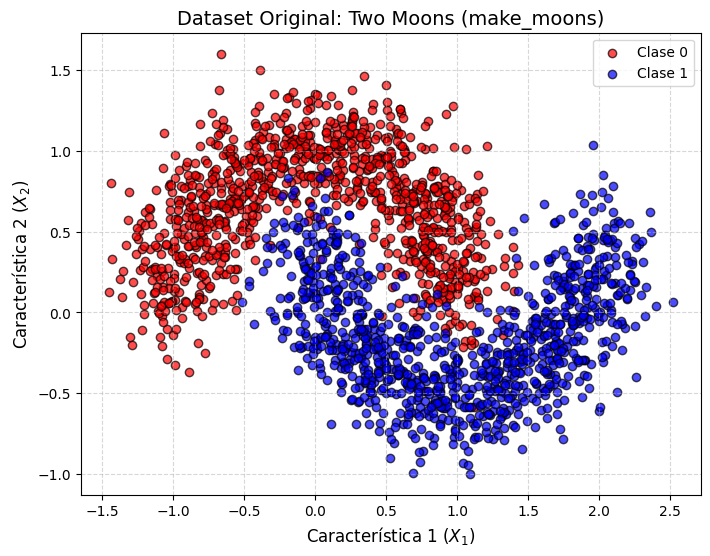

In [ ]:
import matplotlib.pyplot as plt

# Graficar el dataset original make_moons
plt.figure(figsize=(8, 6))

# Puntos de la clase 0
plt.scatter(
    X[y == 0, 0], X[y == 0, 1],
    color='red', label='Clase 0', alpha=0.7, edgecolors='k'
)

# Puntos de la clase 1
plt.scatter(
    X[y == 1, 0], X[y == 1, 1],
    color='blue', label='Clase 1', alpha=0.7, edgecolors='k'
)

plt.title('Dataset Original: Two Moons (make_moons)', fontsize=14)
plt.xlabel('Característica 1 ($X_1$)', fontsize=12)
plt.ylabel('Característica 2 ($X_2$)', fontsize=12)
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

In [ ]:
# ==============================================================================
# 3. ARQUITECTURA DEL MODELO CON SEGUIMIENTO DE NEURONAS
# ==============================================================================
class FlexibleMLP(nn.Module):
    def __init__(self, activation_name="relu"):
        super(FlexibleMLP, self).__init__()
        self.activation_name = activation_name

        self.fc1 = nn.Linear(2, 64)
        self.fc2 = nn.Linear(64, 64)
        self.fc3 = nn.Linear(64, 1)

        # Selección de Activación
        if activation_name == "relu":
            self.act = nn.ReLU()
        elif activation_name == "leaky_relu":
            self.act = nn.LeakyReLU(negative_slope=0.1)
        elif activation_name == "sigmoid":
            self.act = nn.Sigmoid()
        else:
            raise ValueError("Función de activación no soportada.")

        self.out_act = nn.Sigmoid() # Capa final de clasificación binaria

        # Almacenamiento de activaciones intermedias
        self.last_h1_act = None
        self.last_h2_act = None

        # Provocar "Dead ReLU": Inicializar biases muy negativos
        self._handicap_initialization()

    def _handicap_initialization(self):
        # Sesgos negativos fuerzan pre-activaciones <= 0
        nn.init.constant_(self.fc1.bias, -2.5)
        nn.init.constant_(self.fc2.bias, -2.5)

    def forward(self, x):
        h1 = self.act(self.fc1(x))
        h2 = self.act(self.fc2(h1))
        out = self.out_act(self.fc3(h2))

        # Guardar estado de activación para inspección
        self.last_h1_act = h1.detach()
        self.last_h2_act = h2.detach()

        return out

    def get_dead_neurons_ratio(self, data_tensor):
        """
        Calcula la proporción de neuronas que están permanentemente apagadas (output = 0)
        en la última capa oculta a lo largo del dataset completo.
        """
        self.eval()
        with torch.no_grad():
            h1 = self.act(self.fc1(data_tensor))
            h2 = self.act(self.fc2(h1))

            # Una neurona está "muerta" en la muestra si su salida es exacto 0 en todo el batch
            dead_h1 = (h2.sum(dim=0) == 0).float().mean().item()
            return dead_h1

In [ ]:
# ==============================================================================
# 4. BUCLE DE ENTRENAMIENTO Y COMPARATIVA
# ==============================================================================
activations = ["relu", "leaky_relu", "sigmoid"]
history = {act: {"loss": [], "acc": [], "dead_ratio": []} for act in activations}
models = {}

epochs = 100
lr = 0.05
criterion = nn.BCELoss()

for act_name in activations:
    print(f"\n--- Entrenando Modelo con Activación: {act_name.upper()} ---")
    model = FlexibleMLP(activation_name=act_name).to(device)
    optimizer = optim.SGD(model.parameters(), lr=lr)

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0

        for batch_x, batch_y in train_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)

            optimizer.zero_grad()
            outputs = model(batch_x)
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * batch_x.size(0)

        # Métricas por época
        epoch_loss = running_loss / len(train_dataset)

        # Evaluación de Accuracy en Test
        model.eval()
        with torch.no_grad():
            test_preds = model(X_test_t.to(device))
            acc = ((test_preds > 0.5).float() == y_test_t.to(device)).float().mean().item()

            # Ratio de neuronas muertas (Solo aplica a variantes ReLU)
            if act_name in ["relu", "leaky_relu"]:
                dead_ratio = model.get_dead_neurons_ratio(X_train_t.to(device))
            else:
                dead_ratio = 0.0 # Sigmoide sufre de desvanecimiento de gradiente, no de 0 exacto

        history[act_name]["loss"].append(epoch_loss)
        history[act_name]["acc"].append(acc)
        history[act_name]["dead_ratio"].append(dead_ratio)

    models[act_name] = model
    print(f"Resultado Final {act_name} -> Loss: {epoch_loss:.4f} | Test Acc: {acc*100:.2f}%")


--- Entrenando Modelo con Activación: RELU ---
Resultado Final relu -> Loss: 0.6934 | Test Acc: 49.75%

--- Entrenando Modelo con Activación: LEAKY_RELU ---
Resultado Final leaky_relu -> Loss: 0.2852 | Test Acc: 86.75%

--- Entrenando Modelo con Activación: SIGMOID ---
Resultado Final sigmoid -> Loss: 0.3813 | Test Acc: 84.50%


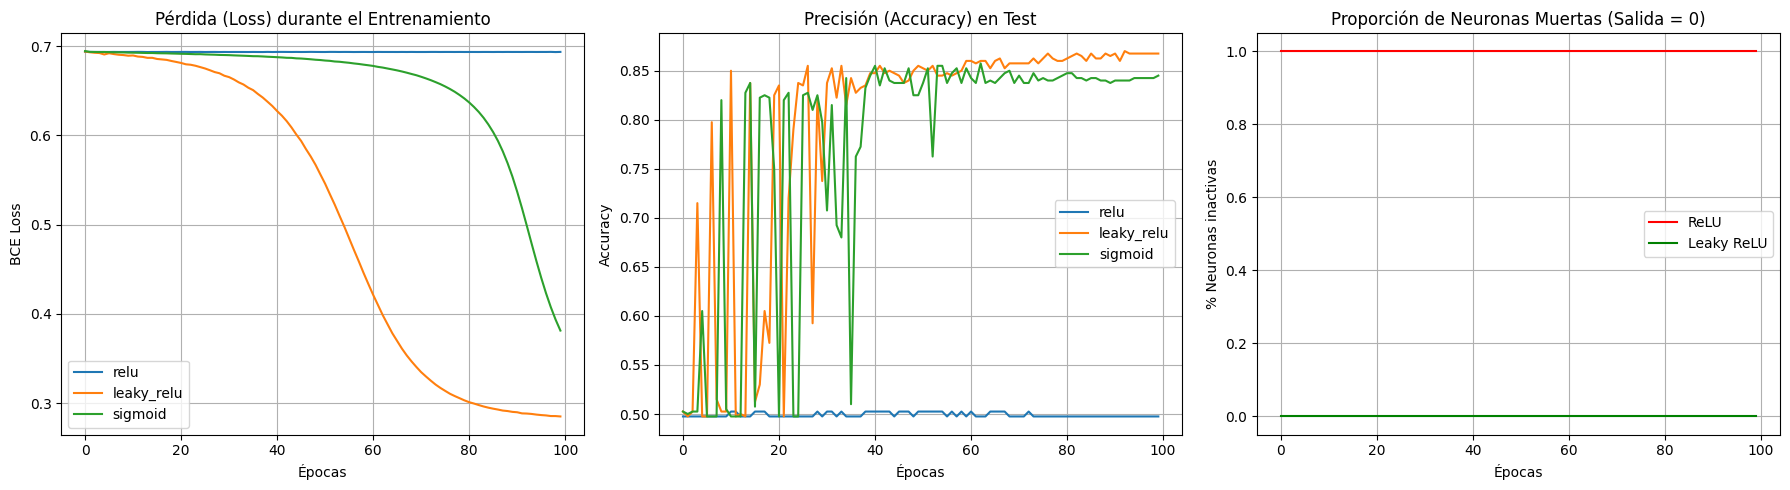

In [ ]:
# ==============================================================================
# 5. VISUALIZACIÓN Y ANÁLISIS COMPARATIVO
# ==============================================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Gráfica de Loss
for act_name in activations:
    axes[0].plot(history[act_name]["loss"], label=f"{act_name}")
axes[0].set_title("Pérdida (Loss) durante el Entrenamiento")
axes[0].set_xlabel("Épocas")
axes[0].set_ylabel("BCE Loss")
axes[0].grid(True)
axes[0].legend()

# 2. Gráfica de Exactitud (Accuracy)
for act_name in activations:
    axes[1].plot(history[act_name]["acc"], label=f"{act_name}")
axes[1].set_title("Precisión (Accuracy) en Test")
axes[1].set_xlabel("Épocas")
axes[1].set_ylabel("Accuracy")
axes[1].grid(True)
axes[1].legend()

# 3. Gráfica de Neuronas Muertas (Dying ReLU)
axes[2].plot(history["relu"]["dead_ratio"], label="ReLU", color="red")
axes[2].plot(history["leaky_relu"]["dead_ratio"], label="Leaky ReLU", color="green")
axes[2].set_title("Proporción de Neuronas Muertas (Salida = 0)")
axes[2].set_xlabel("Épocas")
axes[2].set_ylabel("% Neuronas inactivas")
axes[2].grid(True)
axes[2].legend()

plt.tight_layout()
plt.show()

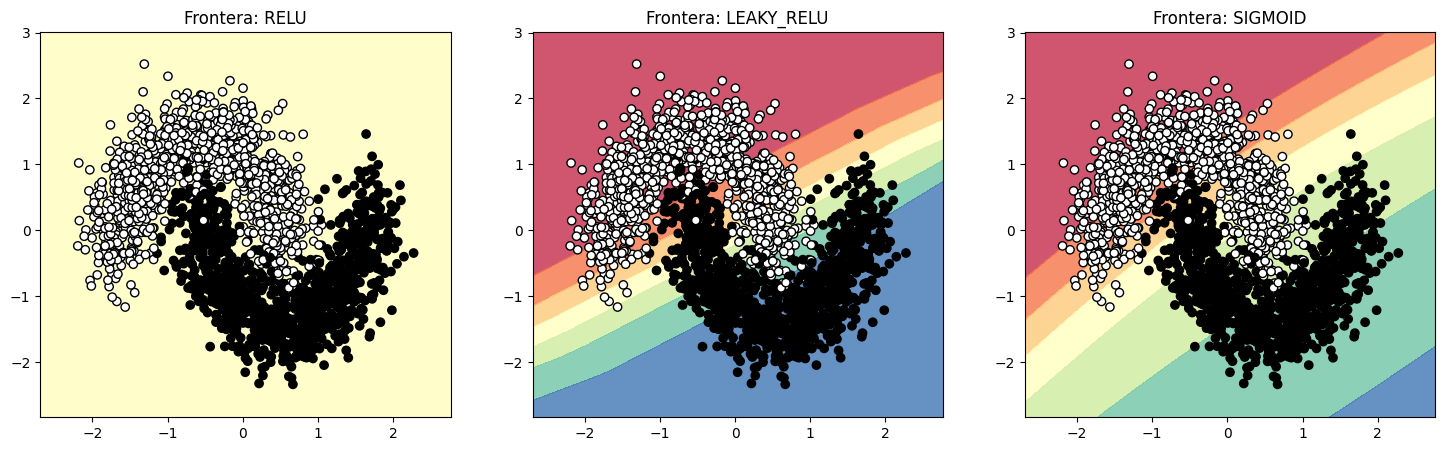

In [ ]:
# ==============================================================================
# 6. VISUALIZACIÓN DE FRONTERAS DE DECISIÓN
# ==============================================================================
def plot_decision_boundary(model, X, y, title):
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                         np.arange(y_min, y_max, 0.02))

    mesh_tensor = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32).to(device)
    model.eval()
    with torch.no_grad():
        Z = model(mesh_tensor).cpu().numpy()
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.Spectral)
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.binary, edgecolors='k')
    plt.title(title)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for idx, act_name in enumerate(activations):
    plt.subplot(1, 3, idx+1)
    plot_decision_boundary(models[act_name], X_scaled, y, f"Frontera: {act_name.upper()}")
plt.show()

Conclusiones claves:

ReLU: Si un sesgo fuerte arrastra a las neuronas al espacio negativo, el porcentaje de neuronas muertas sube hacia el 100%, estancando la pérdida.

Leaky ReLU: Al permitir una leve fuga (α⋅x), repara la red ajustando gradualmente los pesos hacia valores positivos hasta converger a la precisión óptima.  

Sigmoide: Logra entrenar, pero su convergencia es considerablemente más lenta comparada con Leaky ReLU debido al Gradient Vanishing en las capas profundas.